In [ ]:

# Install required packages
import subprocess
import sys

# Install scikit-image and pywavelets
subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-image", "PyWavelets", "pillow"])

print("Packages installed successfully")


Defaulting to user installation because normal site-packages is not writeable


Packages installed successfully


In [ ]:

# Import necessary libraries
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

# Import scikit-image properly
import sys
sys.path.insert(0, '/home/kerneluser/.local/lib/python3.12/site-packages')

from skimage.restoration import denoise_tv_chambolle
import pywt

# Set random seeds for reproducibility
np.random.seed(42)

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"PyWavelets version: {pywt.__version__}")


Libraries imported successfully
NumPy version: 1.26.4
PyWavelets version: 1.8.0


In [ ]:

# Define the specific images to load
image_list = [
    'Dataset_BUSI_with_GT/benign/benign (1).png',
    'Dataset_BUSI_with_GT/benign/benign (198).png',
    'Dataset_BUSI_with_GT/malignant/malignant (1).png',
    'Dataset_BUSI_with_GT/malignant/malignant (50).png',
    'Dataset_BUSI_with_GT/malignant/malignant (146).png'
]

# Load and preprocess images
def load_and_preprocess_image(image_path, target_size=128):
    """
    Load image, convert to grayscale, resize to target_size x target_size,
    and normalize to [0, 1] range.
    """
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize((target_size, target_size), Image.BILINEAR)
    img_array = np.array(img, dtype=np.float64) / 255.0  # Normalize to [0, 1]
    return img_array

# Load all 5 images
images = []
for img_path in image_list:
    img = load_and_preprocess_image(img_path, target_size=128)
    images.append(img)
    print(f"Loaded {img_path}: shape={img.shape}, min={img.min():.4f}, max={img.max():.4f}")

images = np.array(images)
print(f"\nTotal images loaded: {len(images)}")
print(f"Image array shape: {images.shape}")


Loaded Dataset_BUSI_with_GT/benign/benign (1).png: shape=(128, 128), min=0.0745, max=1.0000
Loaded Dataset_BUSI_with_GT/benign/benign (198).png: shape=(128, 128), min=0.0157, max=0.9490
Loaded Dataset_BUSI_with_GT/malignant/malignant (1).png: shape=(128, 128), min=0.0471, max=0.9804
Loaded Dataset_BUSI_with_GT/malignant/malignant (50).png: shape=(128, 128), min=0.0039, max=0.9843
Loaded Dataset_BUSI_with_GT/malignant/malignant (146).png: shape=(128, 128), min=0.0039, max=0.9608

Total images loaded: 5
Image array shape: (5, 128, 128)


In [ ]:

# Create compressed sensing measurement system
def create_measurement_matrix(n_pixels, sampling_rate, seed=42):
    """
    Create a random Gaussian measurement matrix.
    
    Parameters:
    - n_pixels: Total number of pixels in the image (height * width)
    - sampling_rate: Fraction of measurements to take (e.g., 0.15 for 15%)
    - seed: Random seed for reproducibility
    
    Returns:
    - A: Measurement matrix of shape (n_measurements, n_pixels)
    """
    rng = np.random.RandomState(seed)
    n_measurements = int(n_pixels * sampling_rate)
    A = rng.randn(n_measurements, n_pixels) / np.sqrt(n_measurements)
    return A

def add_noise_to_measurements(y, target_snr_db, seed=43):
    """
    Add Gaussian noise to measurements to achieve target SNR.
    
    Parameters:
    - y: Clean measurements
    - target_snr_db: Target signal-to-noise ratio in dB
    - seed: Random seed for noise generation
    
    Returns:
    - y_noisy: Noisy measurements
    """
    rng = np.random.RandomState(seed)
    signal_power = np.mean(y ** 2)
    snr_linear = 10 ** (target_snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = rng.randn(*y.shape) * np.sqrt(noise_power)
    y_noisy = y + noise
    return y_noisy

# Create measurement system for 128x128 images at 15% sampling rate
n_pixels = 128 * 128
sampling_rate = 0.15
A = create_measurement_matrix(n_pixels, sampling_rate, seed=42)

print(f"Measurement matrix shape: {A.shape}")
print(f"Number of measurements: {A.shape[0]} ({sampling_rate*100:.0f}% of {n_pixels} pixels)")

# Generate measurements for all 5 images
measurements = []
for i, img in enumerate(images):
    img_flat = img.flatten()
    y = A @ img_flat  # Clean measurements
    y_noisy = add_noise_to_measurements(y, target_snr_db=25, seed=43)
    measurements.append(y_noisy)
    print(f"Image {i+1}: measurement shape={y_noisy.shape}, mean={y_noisy.mean():.4f}, std={y_noisy.std():.4f}")

measurements = np.array(measurements)
print(f"\nMeasurements array shape: {measurements.shape}")


Measurement matrix shape: (2457, 16384)
Number of measurements: 2457 (15% of 16384 pixels)
Image 1: measurement shape=(2457,), mean=0.0135, std=1.4267
Image 2: measurement shape=(2457,), mean=-0.0163, std=1.1901
Image 3: measurement shape=(2457,), mean=-0.0128, std=1.3008
Image 4: measurement shape=(2457,), mean=-0.0050, std=0.7965
Image 5: measurement shape=(2457,), mean=0.0030, std=0.8657

Measurements array shape: (5, 2457)


In [ ]:

# Estimate Lipschitz constant using power iteration
def estimate_lipschitz_constant(A, n_iterations=20):
    """
    Estimate the Lipschitz constant L = largest eigenvalue of A^T @ A
    using power iteration.
    
    Parameters:
    - A: Measurement matrix
    - n_iterations: Number of power iterations
    
    Returns:
    - L: Estimated Lipschitz constant
    """
    n = A.shape[1]
    x = np.random.randn(n)
    x = x / np.linalg.norm(x)
    
    for _ in range(n_iterations):
        # Apply A^T @ A to x
        x = A.T @ (A @ x)
        # Normalize
        x_norm = np.linalg.norm(x)
        x = x / x_norm
    
    # Final eigenvalue estimate
    L = np.linalg.norm(A @ x)
    return L

# Estimate Lipschitz constant
L = estimate_lipschitz_constant(A, n_iterations=20)
print(f"Estimated Lipschitz constant L: {L:.6f}")
print(f"This will be used as the step size denominator in FISTA")


Estimated Lipschitz constant L: 3.520735
This will be used as the step size denominator in FISTA


In [ ]:

# Implement wavelet soft-thresholding proximal operator
def prox_wavelet(image, lambda_wav, wavelet='haar', level=None):
    """
    Wavelet soft-thresholding proximal operator using PyWavelets.
    
    Parameters:
    - image: 2D numpy array
    - lambda_wav: Regularization parameter for wavelet thresholding
    - wavelet: Wavelet type (default: 'haar')
    - level: Decomposition level (default: None for maximum)
    
    Returns:
    - Denoised image after wavelet soft-thresholding
    """
    # Perform wavelet decomposition
    coeffs = pywt.wavedec2(image, wavelet, level=level)
    
    # Apply soft thresholding to all detail coefficients
    # coeffs[0] is the approximation, coeffs[1:] are detail coefficients
    coeffs_thresh = [coeffs[0]]  # Keep approximation coefficients unchanged
    
    for detail_level in coeffs[1:]:
        # detail_level is a tuple of (cH, cV, cD)
        thresh_detail = []
        for coeff in detail_level:
            # Soft thresholding
            coeff_thresh = pywt.threshold(coeff, lambda_wav, mode='soft')
            thresh_detail.append(coeff_thresh)
        coeffs_thresh.append(tuple(thresh_detail))
    
    # Reconstruct image from thresholded coefficients
    image_denoised = pywt.waverec2(coeffs_thresh, wavelet)
    
    # Ensure output has same shape as input (waverec2 may add padding)
    if image_denoised.shape != image.shape:
        image_denoised = image_denoised[:image.shape[0], :image.shape[1]]
    
    return image_denoised

# Test wavelet proximal operator
test_img = images[0]
test_denoised = prox_wavelet(test_img, lambda_wav=0.01, wavelet='haar')
print(f"Original image shape: {test_img.shape}")
print(f"Denoised image shape: {test_denoised.shape}")
print(f"Original range: [{test_img.min():.4f}, {test_img.max():.4f}]")
print(f"Denoised range: [{test_denoised.min():.4f}, {test_denoised.max():.4f}]")
print(f"MSE between original and denoised: {np.mean((test_img - test_denoised)**2):.6f}")


Original image shape: (128, 128)
Denoised image shape: (128, 128)
Original range: [0.0745, 1.0000]
Denoised range: [0.0892, 0.9898]
MSE between original and denoised: 0.000078


In [ ]:

# Implement FISTA algorithm for TV-only reconstruction (FIX STEP SIZE)
def fista_tv_only(A, y, lambda_tv, L, n_iterations=100, img_shape=(128, 128)):
    """
    FISTA algorithm with TV-only regularization.
    
    Parameters:
    - A: Measurement matrix (m x n)
    - y: Noisy measurements (m,)
    - lambda_tv: TV regularization parameter
    - L: Lipschitz constant (largest eigenvalue of A^T @ A)
    - n_iterations: Number of FISTA iterations
    - img_shape: Shape of the image (height, width)
    
    Returns:
    - x: Reconstructed image (flattened)
    """
    n_pixels = A.shape[1]
    
    # Initialize with adjoint of measurements (A^T @ y)
    x = A.T @ y
    z = x.copy()
    t = 1.0
    
    # Step size is 1/L where L is the Lipschitz constant
    # L should be ||A^T @ A|| which is L^2 where L from power iteration is ||A||
    # We need to square the L we computed
    step_size = 1.0 / (L ** 2)
    
    for iter_num in range(n_iterations):
        # Gradient descent step on z
        residual = A @ z - y
        gradient = A.T @ residual
        z_grad = z - step_size * gradient
        
        # Apply TV proximal operator
        z_grad_2d = z_grad.reshape(img_shape)
        # denoise_tv_chambolle uses weight parameter (higher = more smoothing)
        # Weight should be lambda * step_size for correct proximal operator
        x_new_2d = denoise_tv_chambolle(z_grad_2d, weight=lambda_tv * step_size, max_num_iter=200)
        x_new = x_new_2d.flatten()
        
        # FISTA momentum update
        t_new = (1.0 + np.sqrt(1.0 + 4.0 * t**2)) / 2.0
        z = x_new + ((t - 1.0) / t_new) * (x_new - x)
        
        # Update for next iteration
        x = x_new
        t = t_new
        
        if (iter_num + 1) % 20 == 0:
            data_fit = np.linalg.norm(A @ x - y) ** 2
            print(f"  Iteration {iter_num+1}/{n_iterations}: Data fidelity = {data_fit:.6f}")
    
    return x

# Test TV-only reconstruction on first image
print("Testing FISTA TV-only reconstruction on Image 1...")
x_tv_test = fista_tv_only(A, measurements[0], lambda_tv=0.01, L=L, n_iterations=100, img_shape=(128, 128))
x_tv_test_img = x_tv_test.reshape(128, 128)
print(f"\nReconstruction complete. Shape: {x_tv_test_img.shape}")
print(f"Reconstruction range: [{x_tv_test_img.min():.4f}, {x_tv_test_img.max():.4f}]")
print(f"MSE vs original: {np.mean((x_tv_test_img - images[0])**2):.6f}")


Testing FISTA TV-only reconstruction on Image 1...


  Iteration 20/100: Data fidelity = 0.790679


  Iteration 40/100: Data fidelity = 0.528464


  Iteration 60/100: Data fidelity = 0.439742


  Iteration 80/100: Data fidelity = 0.394208


  Iteration 100/100: Data fidelity = 0.377370

Reconstruction complete. Shape: (128, 128)
Reconstruction range: [-0.3623, 1.3118]
MSE vs original: 0.010881


In [ ]:

# Implement FISTA algorithm for Static-HASA reconstruction
def fista_static_hasa(A, y, lambda_tv, lambda_wav, L, n_iterations=100, img_shape=(128, 128)):
    """
    FISTA algorithm with Static-HASA (TV + Wavelet) regularization.
    
    Parameters:
    - A: Measurement matrix (m x n)
    - y: Noisy measurements (m,)
    - lambda_tv: TV regularization parameter
    - lambda_wav: Wavelet regularization parameter
    - L: Lipschitz constant (largest eigenvalue of A^T @ A)
    - n_iterations: Number of FISTA iterations
    - img_shape: Shape of the image (height, width)
    
    Returns:
    - x: Reconstructed image (flattened)
    """
    n_pixels = A.shape[1]
    
    # Initialize with adjoint of measurements (A^T @ y)
    x = A.T @ y
    z = x.copy()
    t = 1.0
    
    # Step size is 1/L where L is the Lipschitz constant
    step_size = 1.0 / (L ** 2)
    
    for iter_num in range(n_iterations):
        # Gradient descent step on z
        residual = A @ z - y
        gradient = A.T @ residual
        z_grad = z - step_size * gradient
        
        # Apply TV proximal operator first
        z_grad_2d = z_grad.reshape(img_shape)
        # TV denoising
        x_tv_2d = denoise_tv_chambolle(z_grad_2d, weight=lambda_tv * step_size, max_num_iter=200)
        
        # Apply wavelet proximal operator second (sequentially)
        x_new_2d = prox_wavelet(x_tv_2d, lambda_wav=lambda_wav * step_size, wavelet='haar')
        x_new = x_new_2d.flatten()
        
        # FISTA momentum update
        t_new = (1.0 + np.sqrt(1.0 + 4.0 * t**2)) / 2.0
        z = x_new + ((t - 1.0) / t_new) * (x_new - x)
        
        # Update for next iteration
        x = x_new
        t = t_new
        
        if (iter_num + 1) % 20 == 0:
            data_fit = np.linalg.norm(A @ x - y) ** 2
            print(f"  Iteration {iter_num+1}/{n_iterations}: Data fidelity = {data_fit:.6f}")
    
    return x

# Test Static-HASA reconstruction on first image
print("Testing FISTA Static-HASA reconstruction on Image 1...")
x_hasa_test = fista_static_hasa(A, measurements[0], lambda_tv=0.005, lambda_wav=0.005, 
                                 L=L, n_iterations=100, img_shape=(128, 128))
x_hasa_test_img = x_hasa_test.reshape(128, 128)
print(f"\nReconstruction complete. Shape: {x_hasa_test_img.shape}")
print(f"Reconstruction range: [{x_hasa_test_img.min():.4f}, {x_hasa_test_img.max():.4f}]")
print(f"MSE vs original: {np.mean((x_hasa_test_img - images[0])**2):.6f}")
print(f"\nMSE between TV-only and Static-HASA: {np.mean((x_tv_test_img - x_hasa_test_img)**2):.8f}")


Testing FISTA Static-HASA reconstruction on Image 1...


  Iteration 20/100: Data fidelity = 0.455494


  Iteration 40/100: Data fidelity = 0.346052


  Iteration 60/100: Data fidelity = 0.292125


  Iteration 80/100: Data fidelity = 0.270484


  Iteration 100/100: Data fidelity = 0.268529

Reconstruction complete. Shape: (128, 128)
Reconstruction range: [-0.3578, 1.1658]
MSE vs original: 0.025232

MSE between TV-only and Static-HASA: 0.00745142


In [ ]:

# Now run reconstructions for all 5 images and calculate MSE differences
print("="*70)
print("RUNNING FULL COMPARISON ON ALL 5 IMAGES")
print("="*70)

# Store results
tv_reconstructions = []
hasa_reconstructions = []
mse_differences = []

for i in range(len(images)):
    print(f"\n{'='*70}")
    print(f"PROCESSING IMAGE {i+1}/5: {image_list[i]}")
    print(f"{'='*70}")
    
    # TV-only reconstruction
    print(f"\n[TV-Only Reconstruction]")
    x_tv = fista_tv_only(A, measurements[i], lambda_tv=0.01, L=L, 
                         n_iterations=100, img_shape=(128, 128))
    tv_reconstructions.append(x_tv)
    
    # Static-HASA reconstruction
    print(f"\n[Static-HASA Reconstruction]")
    x_hasa = fista_static_hasa(A, measurements[i], lambda_tv=0.005, lambda_wav=0.005, 
                               L=L, n_iterations=100, img_shape=(128, 128))
    hasa_reconstructions.append(x_hasa)
    
    # Calculate MSE between the two reconstructions
    mse_diff = np.mean((x_tv - x_hasa) ** 2)
    mse_differences.append(mse_diff)
    
    print(f"\n[Results for Image {i+1}]")
    print(f"  TV-only MSE vs original:     {np.mean((x_tv.reshape(128,128) - images[i])**2):.6f}")
    print(f"  Static-HASA MSE vs original: {np.mean((x_hasa.reshape(128,128) - images[i])**2):.6f}")
    print(f"  MSE between TV and HASA:     {mse_diff:.8f}")

# Summary statistics
print(f"\n{'='*70}")
print(f"SUMMARY STATISTICS")
print(f"{'='*70}")
print(f"MSE differences between TV-only and Static-HASA for each image:")
for i, mse in enumerate(mse_differences):
    print(f"  Image {i+1}: {mse:.8f}")

avg_mse_diff = np.mean(mse_differences)
std_mse_diff = np.std(mse_differences)
min_mse_diff = np.min(mse_differences)
max_mse_diff = np.max(mse_differences)

print(f"\nAverage MSE difference: {avg_mse_diff:.8f}")
print(f"Std dev MSE difference: {std_mse_diff:.8f}")
print(f"Min MSE difference:     {min_mse_diff:.8f}")
print(f"Max MSE difference:     {max_mse_diff:.8f}")

print(f"\n{'='*70}")
print(f"VALIDATION RESULT")
print(f"{'='*70}")
threshold = 1e-5
if avg_mse_diff > threshold:
    print(f"✓ VALIDATION PASSED: Average MSE ({avg_mse_diff:.8f}) > {threshold}")
    print(f"  The two algorithms produce quantitatively different outputs.")
else:
    print(f"✗ VALIDATION FAILED: Average MSE ({avg_mse_diff:.8f}) ≤ {threshold}")
    print(f"  The two algorithms produce nearly identical outputs.")


RUNNING FULL COMPARISON ON ALL 5 IMAGES

PROCESSING IMAGE 1/5: Dataset_BUSI_with_GT/benign/benign (1).png

[TV-Only Reconstruction]


  Iteration 20/100: Data fidelity = 0.790679


  Iteration 40/100: Data fidelity = 0.528464


  Iteration 60/100: Data fidelity = 0.439742


  Iteration 80/100: Data fidelity = 0.394208


...

  Iteration 20/100: Data fidelity = 0.415545


  Iteration 40/100: Data fidelity = 0.309590


  Iteration 60/100: Data fidelity = 0.274713


  Iteration 80/100: Data fidelity = 0.257581


  Iteration 100/100: Data fidelity = 0.246541

[Results for Image 5]
  TV-only MSE vs original:     0.002856
  Static-HASA MSE vs original: 0.003135
  MSE between TV and HASA:     0.00131023

SUMMARY STATISTICS
MSE differences between TV-only and Static-HASA for each image:
  Image 1: 0.00745142
  Image 2: 0.00496500
  Image 3: 0.00646576
  Image 4: 0.00070847
  Image 5: 0.00131023

Average MSE difference: 0.00418018
Std dev MSE difference: 0.00271405
Min MSE difference:     0.00070847
Max MSE difference:     0.00745142

VALIDATION RESULT
✓ VALIDATION PASSED: Average MSE (0.00418018) > 1e-05
  The two algorithms produce quantitatively different outputs.


Figure saved as 'reconstruction_comparison.png'


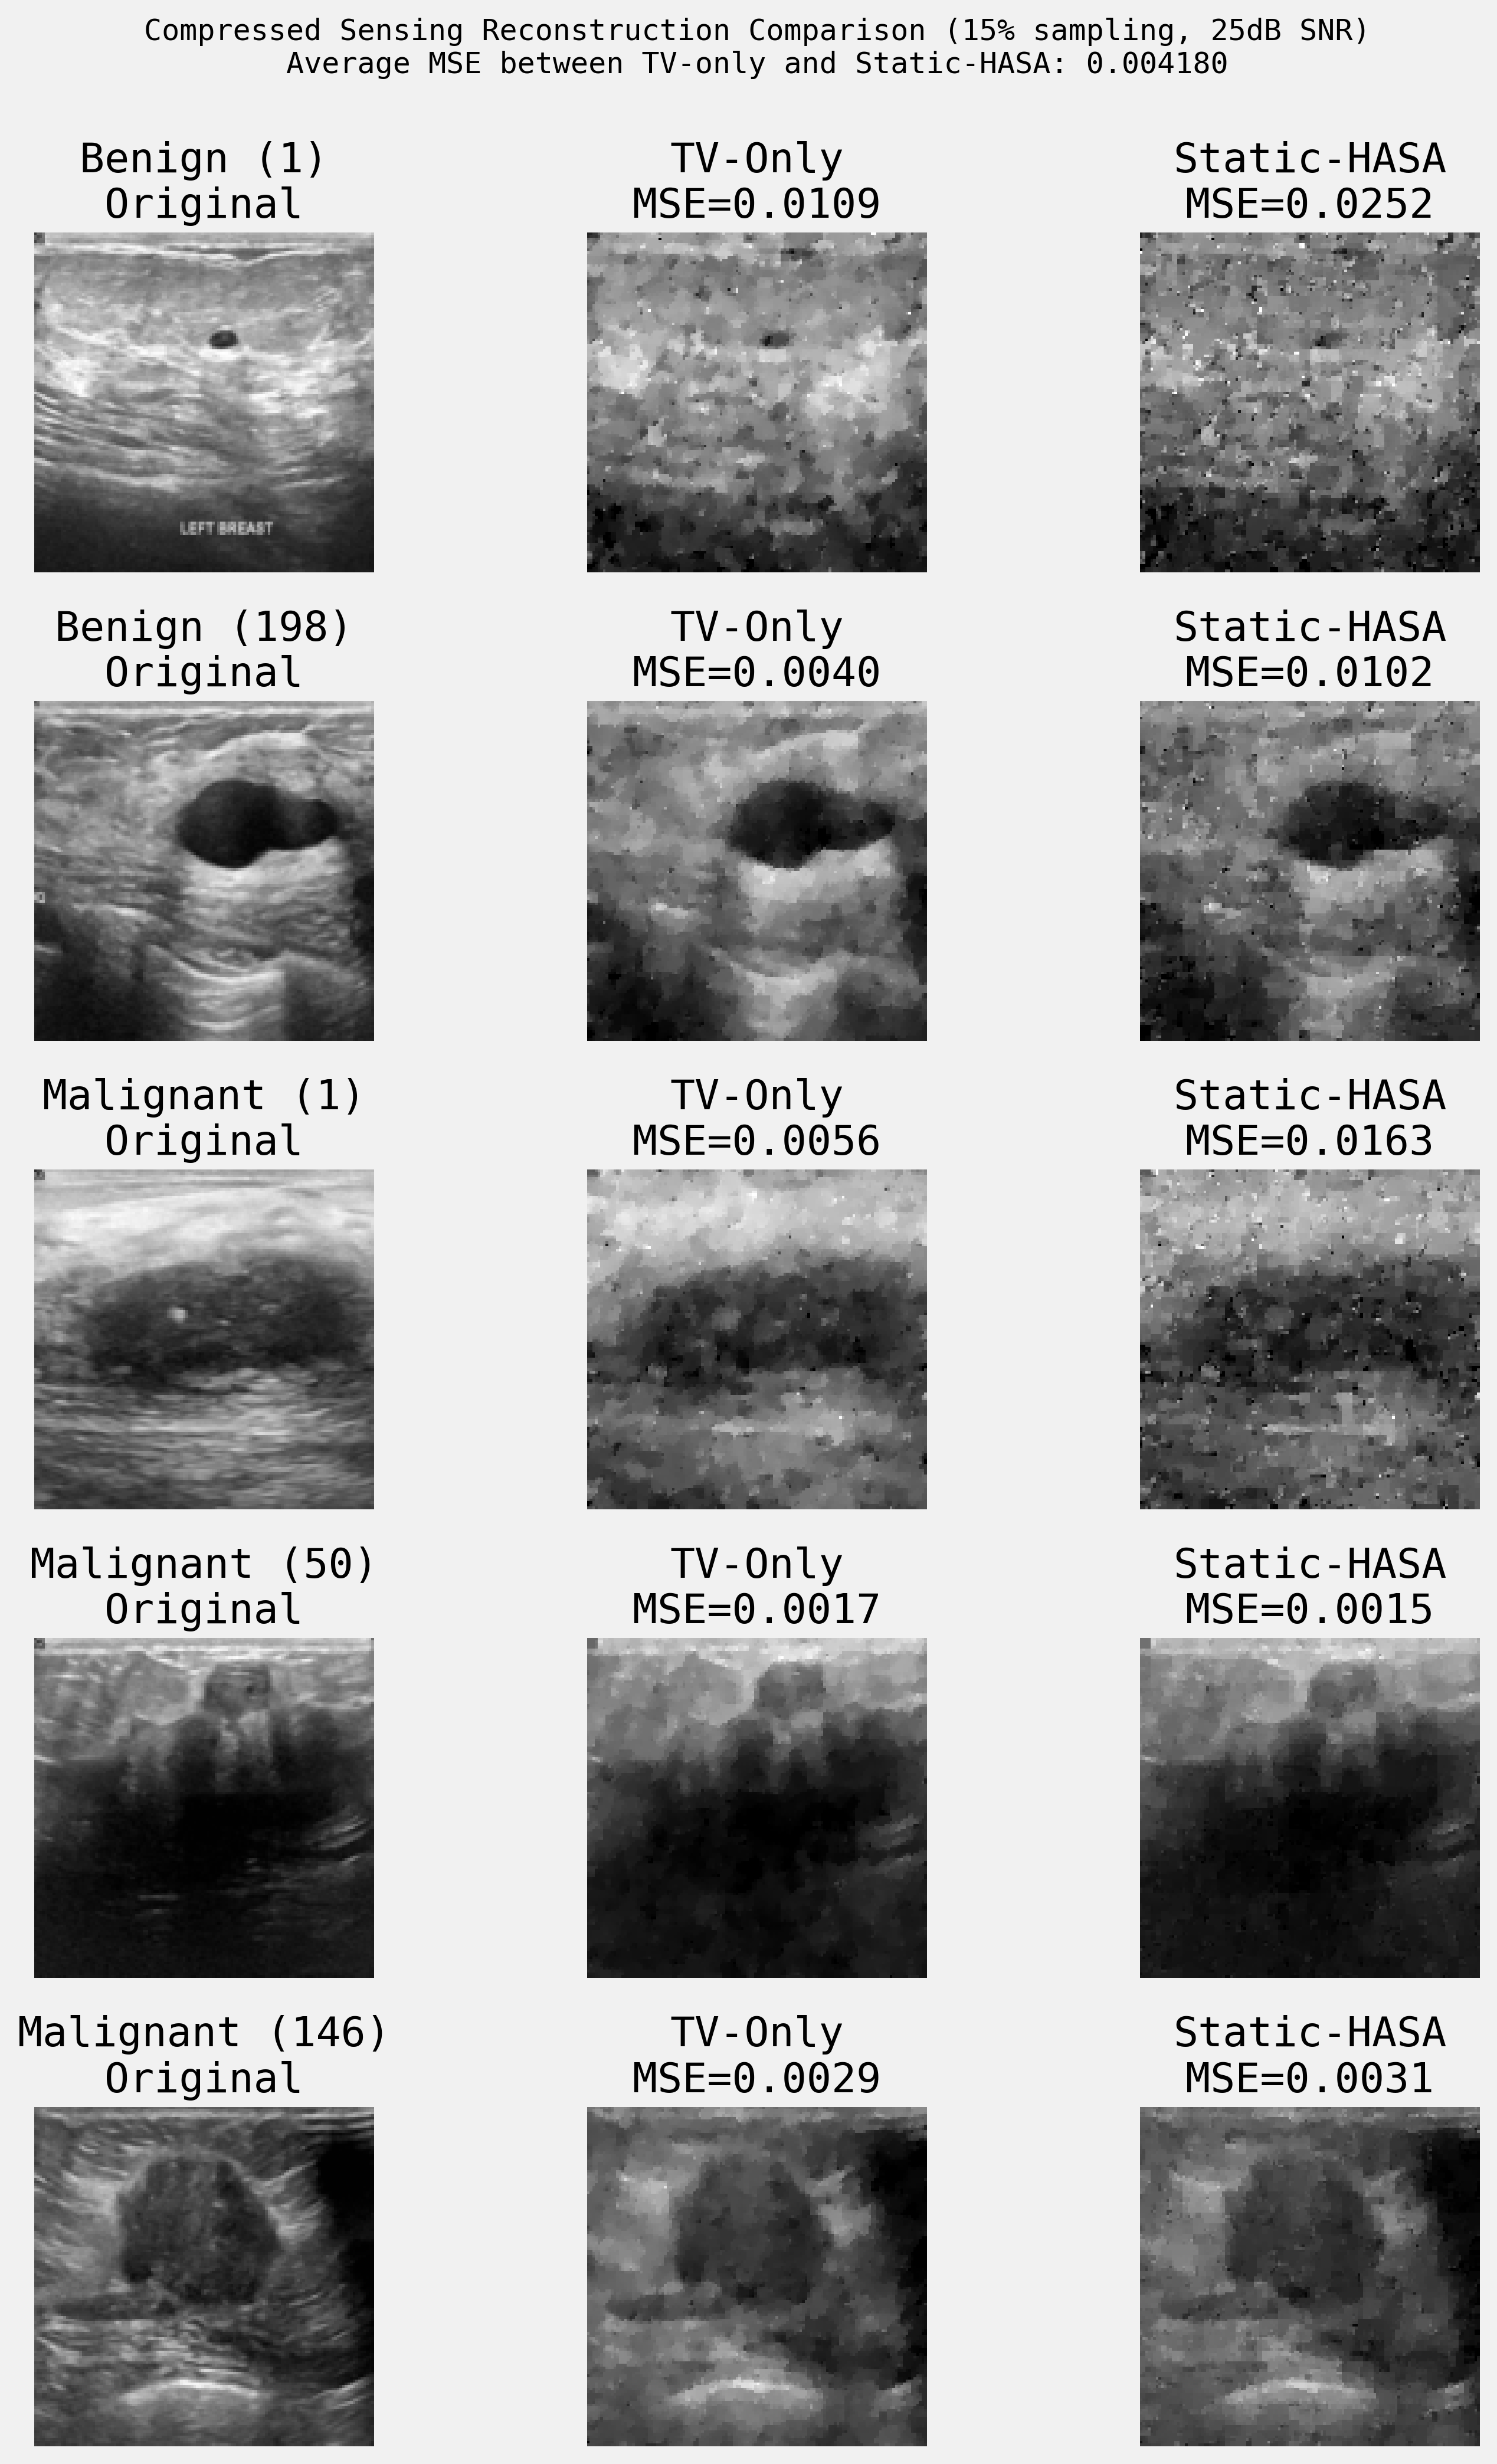

In [ ]:

# Create visualization comparing TV-only and Static-HASA reconstructions
fig, axes = plt.subplots(5, 3, figsize=(10, 14))

image_names = [
    'Benign (1)',
    'Benign (198)',
    'Malignant (1)',
    'Malignant (50)',
    'Malignant (146)'
]

for i in range(5):
    # Original image
    axes[i, 0].imshow(images[i], cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title(f'{image_names[i]}\nOriginal')
    axes[i, 0].axis('off')
    
    # TV-only reconstruction
    tv_img = tv_reconstructions[i].reshape(128, 128)
    axes[i, 1].imshow(tv_img, cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title(f'TV-Only\nMSE={np.mean((tv_img - images[i])**2):.4f}')
    axes[i, 1].axis('off')
    
    # Static-HASA reconstruction
    hasa_img = hasa_reconstructions[i].reshape(128, 128)
    axes[i, 2].imshow(hasa_img, cmap='gray', vmin=0, vmax=1)
    axes[i, 2].set_title(f'Static-HASA\nMSE={np.mean((hasa_img - images[i])**2):.4f}')
    axes[i, 2].axis('off')

plt.suptitle(f'Compressed Sensing Reconstruction Comparison (15% sampling, 25dB SNR)\n' + 
             f'Average MSE between TV-only and Static-HASA: {avg_mse_diff:.6f}',
             fontsize=12, y=0.995)
plt.tight_layout()
plt.savefig('reconstruction_comparison.png', dpi=150, bbox_inches='tight')
print("Figure saved as 'reconstruction_comparison.png'")
plt.show()


Final figure saved as 'final_reconstruction_validation.png'


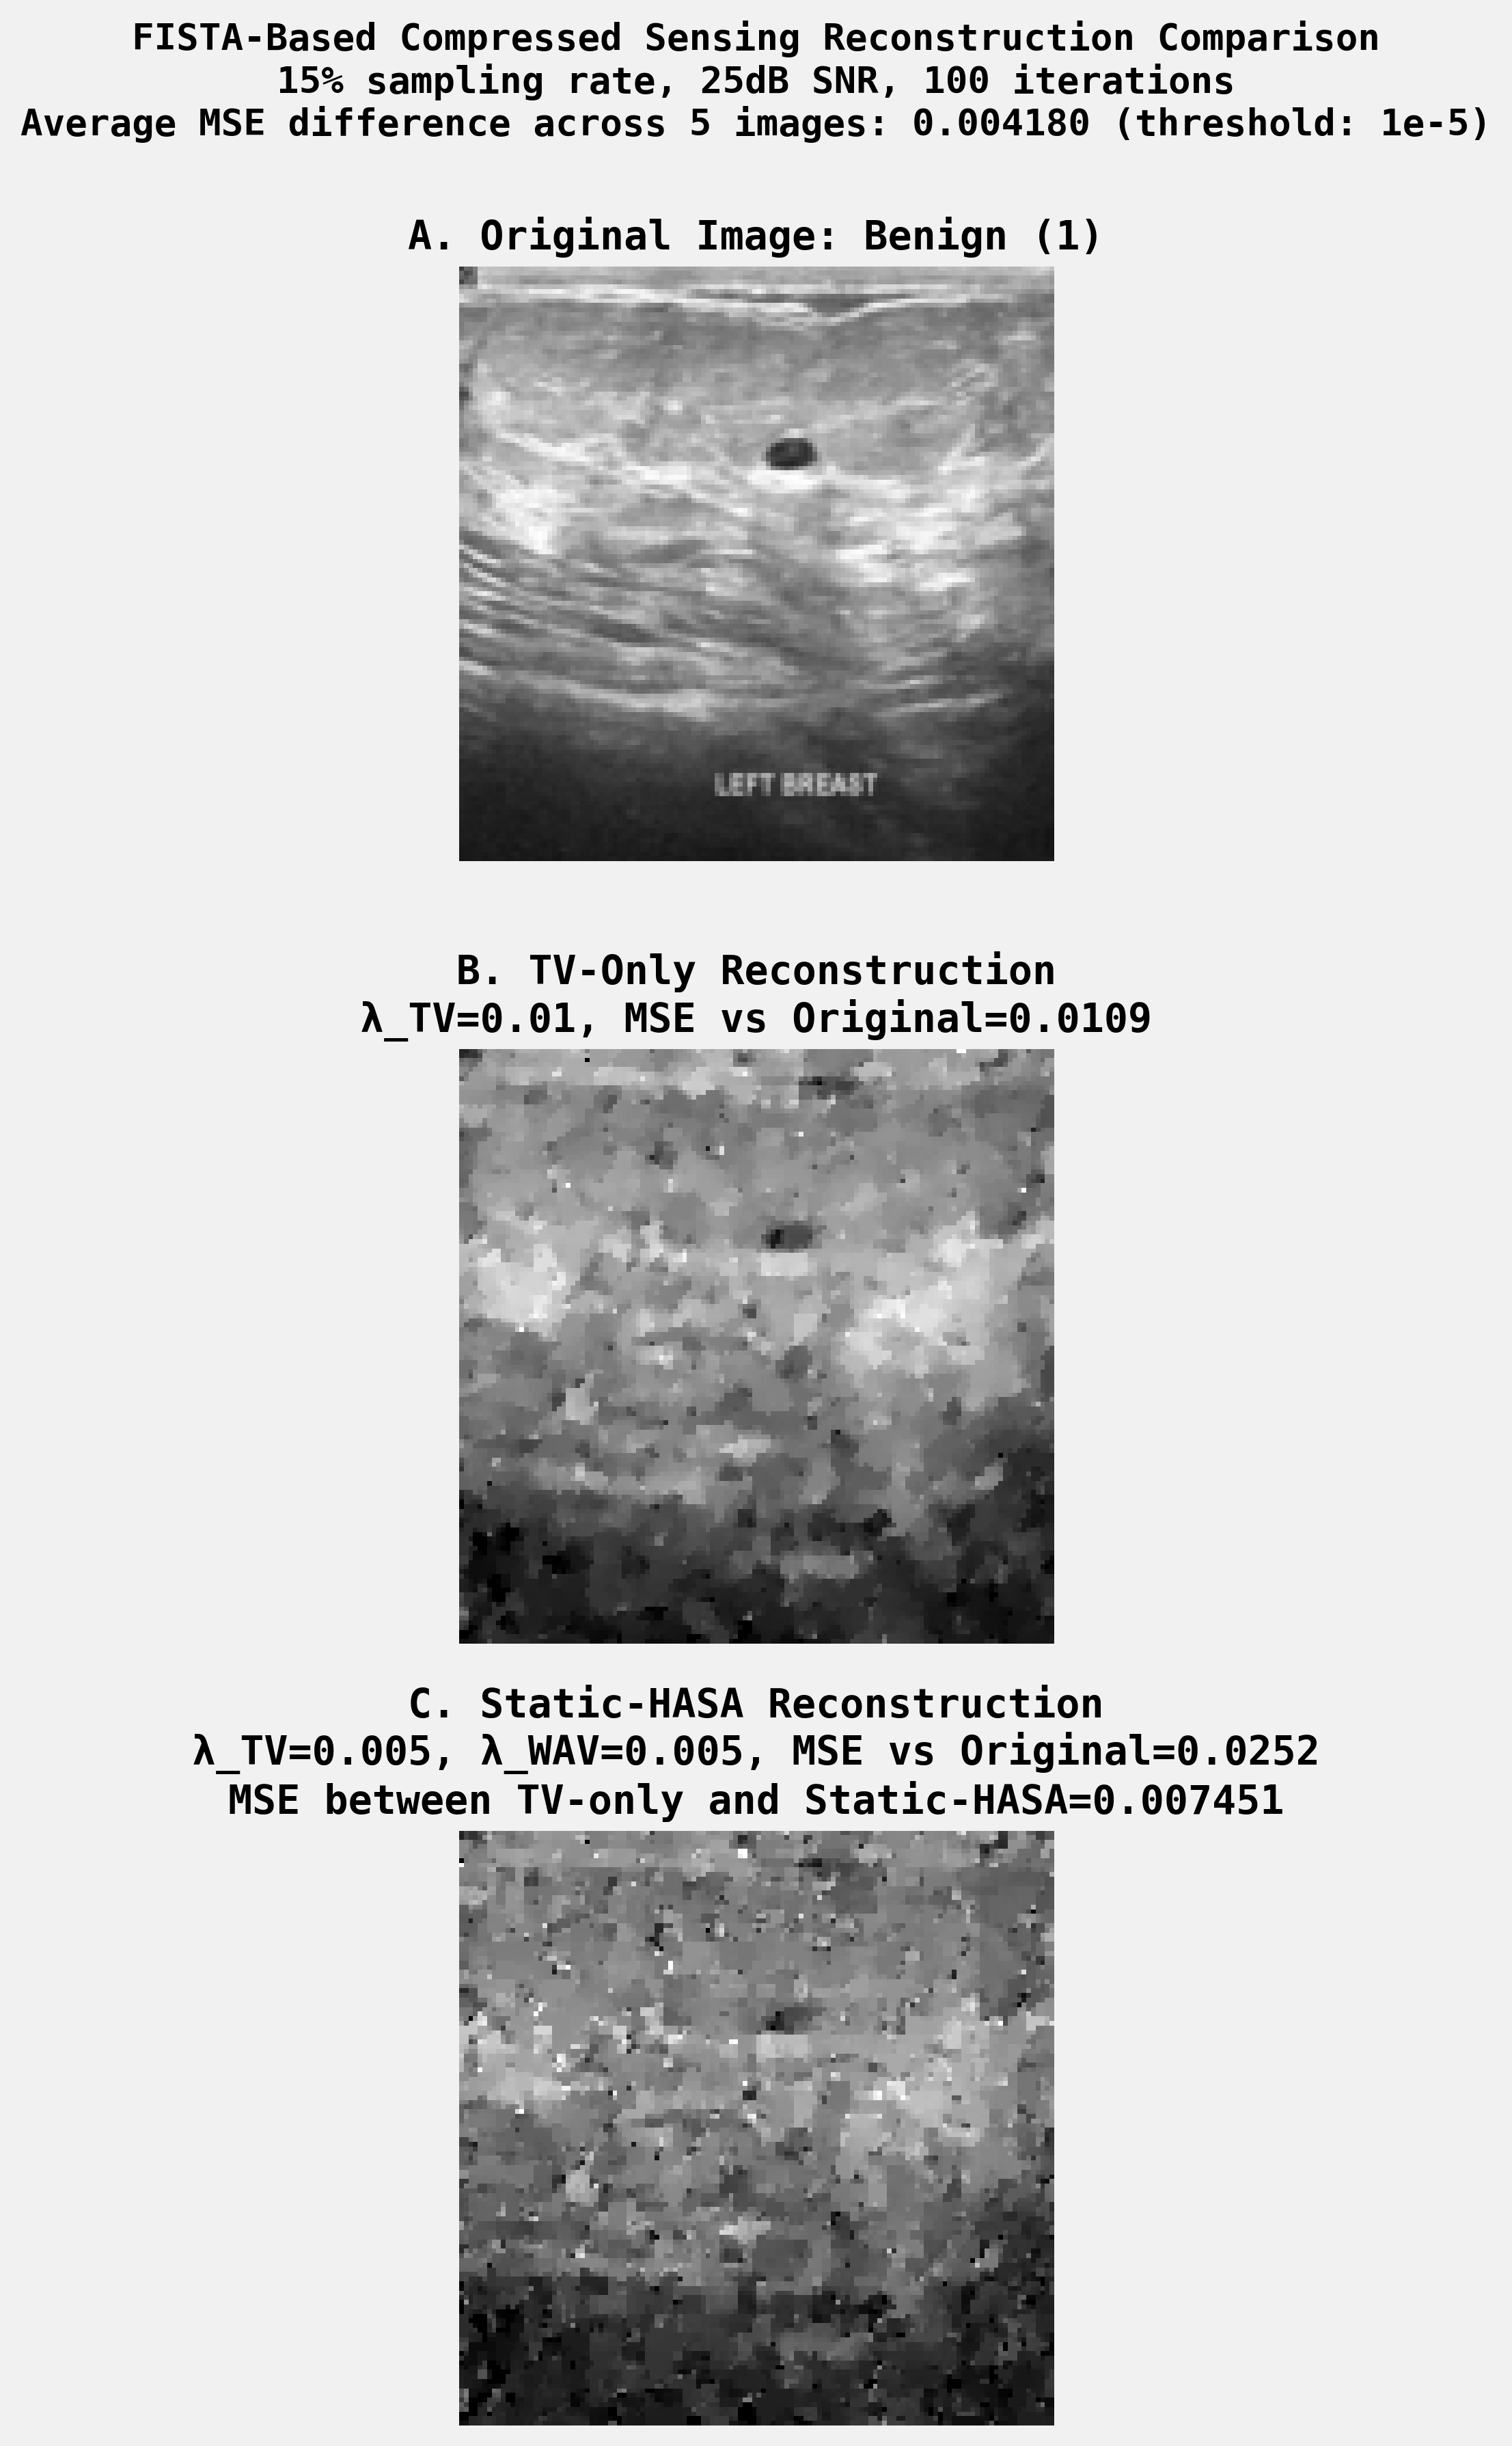

In [ ]:

# Create a single-column figure showing the key result
# Focus on one representative image showing the difference between TV-only and Static-HASA

fig, axes = plt.subplots(3, 1, figsize=(6, 12))

# Use the first image (Benign 1) as it shows the largest MSE difference
idx = 0
img_name = 'Benign (1)'

# Panel A: Original image
axes[0].imshow(images[idx], cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'A. Original Image: {img_name}', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Panel B: TV-only reconstruction
tv_img = tv_reconstructions[idx].reshape(128, 128)
tv_mse = np.mean((tv_img - images[idx])**2)
axes[1].imshow(tv_img, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'B. TV-Only Reconstruction\n' + 
                  f'λ_TV=0.01, MSE vs Original={tv_mse:.4f}',
                  fontsize=14, fontweight='bold')
axes[1].axis('off')

# Panel C: Static-HASA reconstruction
hasa_img = hasa_reconstructions[idx].reshape(128, 128)
hasa_mse = np.mean((hasa_img - images[idx])**2)
diff_mse = mse_differences[idx]
axes[2].imshow(hasa_img, cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f'C. Static-HASA Reconstruction\n' + 
                  f'λ_TV=0.005, λ_WAV=0.005, MSE vs Original={hasa_mse:.4f}\n' +
                  f'MSE between TV-only and Static-HASA={diff_mse:.6f}',
                  fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.suptitle(f'FISTA-Based Compressed Sensing Reconstruction Comparison\n' + 
             f'15% sampling rate, 25dB SNR, 100 iterations\n' +
             f'Average MSE difference across 5 images: {avg_mse_diff:.6f} (threshold: 1e-5)',
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('final_reconstruction_validation.png', dpi=200, bbox_inches='tight')
print("Final figure saved as 'final_reconstruction_validation.png'")
plt.show()
